En esta tarea semanal se busca analizar el derrame espectral de densidad de potencia para frecuencias que estan entremedio de los bins determinados por el resolucion espectal. Para esto se generaran tres señales sinusoidales con distintas frecuancia: 250Hz, 250,5Hz y 250,25Hz. Estas ultimas dos, no son multiplos enteros de la resolucion espectral. A continuacion se obervará graficamente qué sucede en la densidad espectral de potencia para las tres señales. 

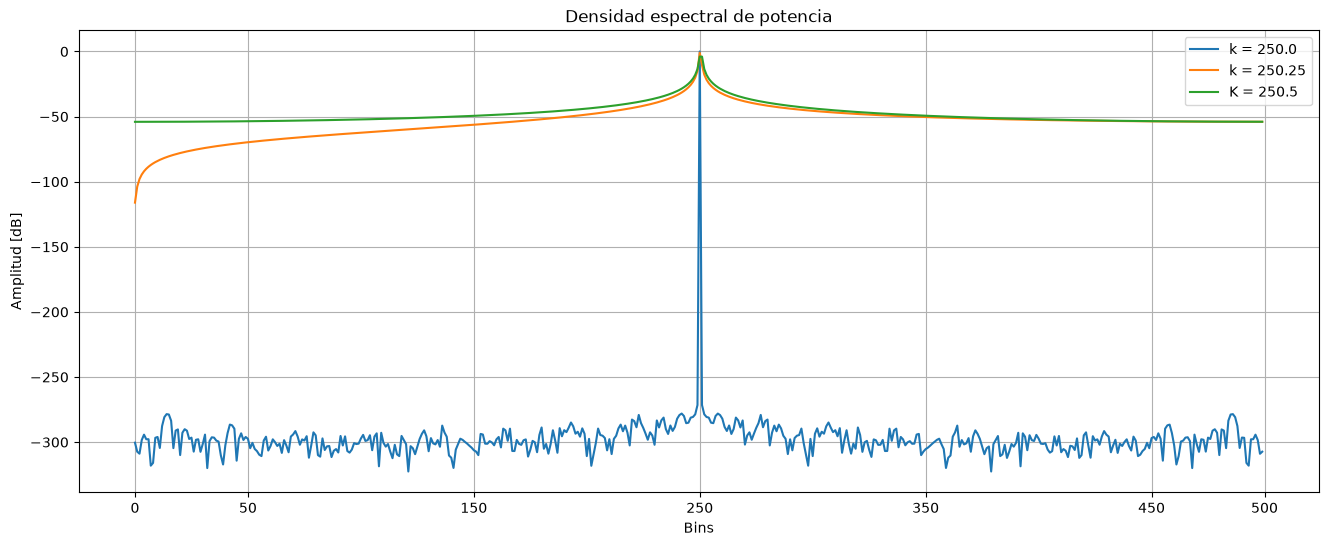

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Sep 10 13:53:36 2026

@author: bruno
"""
import numpy as np
import matplotlib.pyplot as plt

## parameros universales
fs = 1000              # frecuencia de muestreo
N = 1000               # muestras
nn = np.arange(0,N)    # vector de muestras
df = fs/N              # Delta f
k0 = N/4
k1 = N/4 + 0.25
k2 = N/4 + 0.5
frec = np.arange(N//2) * df  # vector de frecuencia
tt = nn/fs


def mdbn (señal):                           # devuelve el modulo de la señal normalizado en 0dB
    señal_tr = (1/N) * np.fft.fft(señal)    # fft normalizada de la señal 
    modulo_señal = 2*(np.abs(señal_tr)**2)         # pone 0dB como referencia de 1W de potencia
    # return (modulo_señal[:N//2])
    modulo_señal_db = 10 * np.log10((modulo_señal[:N//2]))   # pone 0dB como referencia de 1W de potencia
    return (modulo_señal_db)

def parseval (señal):                           # devuelve el modulo de la señal normalizado en 0dB
    señal_tr = (1/N) * np.fft.fft(señal)    # fft normalizada de la señal 
    modulo_señal = 2*(np.abs(señal_tr)**2)         # pone 0dB como referencia de 1W de potencia
    return (modulo_señal[:N//2])

# =============================================================================
#                       visualizacon del derrame espectral
# =============================================================================
vmax = np.sqrt(2)
xx0 = vmax*np.sin(2*np.pi* k0*df *nn/fs)
xx1 = vmax*np.sin(2*np.pi* k1*df *nn/fs)
xx2 = vmax*np.sin(2*np.pi* k2*df *nn/fs)

xx0tr = mdbn(xx0)
xx1tr = mdbn(xx1)
xx2tr = mdbn(xx2)

plt.figure(1, figsize=(16,6))
plt.grid(True)
plt.plot(frec, xx0tr)
plt.plot(frec, xx1tr)
plt.plot(frec, xx2tr)
plt.title("Densidad espectral de potencia")
plt.xlabel("Bins")
plt.ylabel("Amplitud [dB]")
plt.xticks([0,50,150,250,350,450,500])
plt.legend([f'k = {k0}',
            f'k = {k1}',
            f'K = {k2}'])
plt.show()

Las señales cuyas frecuencias no son multilpos de enteros de las resolucion espectral tienen pisos de ruido mas elevados resultado del derrame espectral porque las señales de 250,5Hz y 250,25Hz porque no tienen ciclos completos en 1000 muestras.

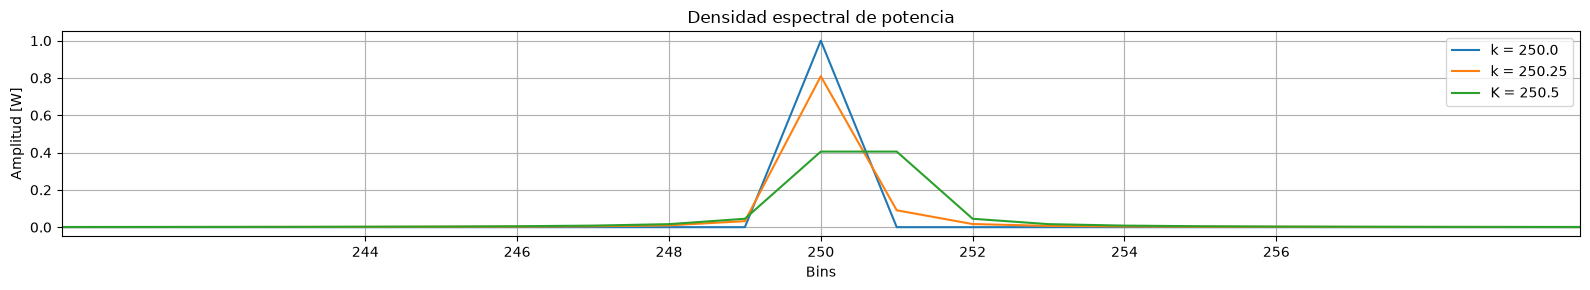

Potencia de señal 250.0 = 1.0000000000000002
Potencia de señal 250.25 = 0.9989979968559346
Potencia de señal 250.5 = 0.9999999748670528


In [2]:
xx0tr_pot = parseval(xx0)
xx1tr_pot = parseval(xx1)
xx2tr_pot = parseval(xx2)

plt.figure(2, figsize=(16,3))
plt.grid(True)
plt.plot(frec, xx0tr_pot)
plt.plot(frec, xx1tr_pot)
plt.plot(frec, xx2tr_pot)
plt.title("Densidad espectral de potencia")
plt.xlabel("Bins")
plt.ylabel("Amplitud [W]")
plt.xlim(240, 260)
plt.xticks([244, 246, 248, 250, 252, 254, 256])
plt.legend([f'k = {k0}',
            f'k = {k1}',
            f'K = {k2}'])
plt.tight_layout()
plt.show()
print(f'Potencia de señal {k0} = {np.sum(xx0tr_pot)}')
print(f'Potencia de señal {k1} = {np.sum(xx1tr_pot)}')
print(f'Potencia de señal {k2} = {np.sum(xx2tr_pot)}')

Se observa que la densidad espectral de potencia de las tres señales no tiene la misma distribucion. Sin embargo, el area bajo la curva (la potencia) de las tres señales es practicamente la misma. A esto se lo conoce como derrame espectral: la potencia de las señales cuya frecuencia no caen en un bin, se reparten en los bins adyacentes. Esto se observa claramente para la señal de 250,5Hz, que tiene sus maximos en 250Hz y en 251Hz.

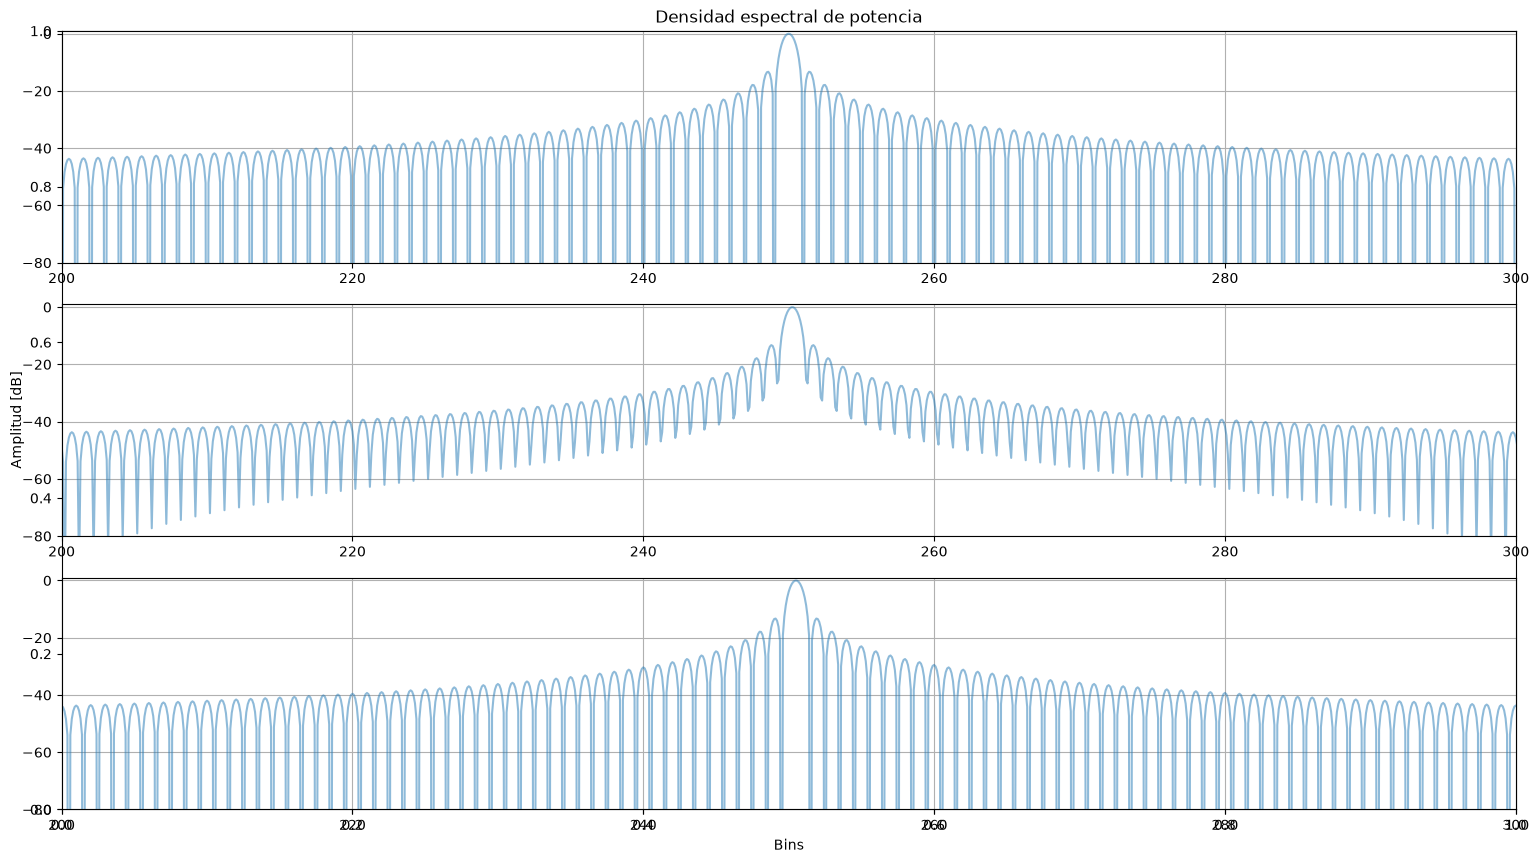

In [3]:
# =============================================================================
#                       ahora haciendo zero padding
# =============================================================================
N_pad = 10*N
df_pad = fs/N_pad
nn_pad = np.arange(0,N_pad)
frec_pad = nn_pad[:N_pad//2] * df_pad
tt_pad=nn_pad/fs


def mdbnpad (señal):                           # devuelve el modulo de la señal normalizado en 0dB
    señal_tr = (1/N) * np.fft.fft(señal)   # fft normalizada de la señal 
    modulo_señal = 2*np.abs(señal_tr)**2          # pone 0dB como referencia de 1W de potencia
    # return (modulo_señal[:N_pad//2])
    modulo_señal_db = 10 * np.log10((modulo_señal[:N_pad//2]))   # pone 0dB como referencia de 1W de potencia
    return (modulo_señal_db[:N_pad//2])

def parseval_pad (señal):                           # devuelve el modulo de la señal normalizado en 0dB
    señal_tr = (1/N) * np.fft.fft(señal)    # fft normalizada de la señal 
    modulo_señal = 2*(np.abs(señal_tr)**2)         # pone 0dB como referencia de 1W de potencia
    return (modulo_señal[:N_pad//2]) * (N/N_pad)
    
#xx padeado agregando 9*N ceros
xx0_pad = np.pad(xx0, (0, 9*N), constant_values=0)
xx1_pad = np.pad(xx1, (0, 9*N), constant_values=0)
xx2_pad = np.pad(xx2, (0, 9*N), constant_values=0)

xx0tr_pad = mdbnpad(xx0_pad)
xx1tr_pad = mdbnpad(xx1_pad)
xx2tr_pad = mdbnpad(xx2_pad)

# %%
plt.figure(4, figsize=(16,9))
plt.title("Densidad espectral de potencia")
plt.xlabel("Bins")
plt.ylabel("Amplitud [dB]")
plt.legend([f'k = {k0}',
            f'k = {k1}',
            f'K = {k2}'])
plt.subplot(3,1,1)
plt.grid(True)
plt.plot(frec_pad, xx0tr_pad, alpha = 0.5)
plt.ylim(-80,1)
plt.xlim(200, 300)
plt.subplot(3,1,2)
plt.grid(True)
plt.plot(frec_pad, xx1tr_pad, alpha = 0.5)
plt.ylim(-80,1)
plt.xlim(200, 300)
plt.subplot(3,1,3)
plt.grid(True)
plt.plot(frec_pad, xx2tr_pad, alpha = 0.5)
plt.ylim(-80,1)
plt.xlim(200, 300)
plt.subplots_adjust(hspace=0.3)
plt.tight_layout()
plt.show()
# print(f'Potencia de señal {k0} = {np.sum(parseval(xx0_pad))}')
# print(f'Potencia de señal {k1} = {np.sum(parseval(xx1_pad))}')
# print(f'Potencia de señal {k2} = {np.sum(parseval(xx2_pad))}')

La tecnica de zero-padding consiste en agregar muestras de ceros al final de la señal muestreada con el objetivo de aumentar la resolucion espectal sin agregar energia a la señal. En este experimento se agregaron 9000 muestras al final de cada señal y se realizo el diagrama espectral de potencia. Se observa que ahora la resolucion espectral es de 0,1 por lo tanto la señal de frecuencia 250.5Hz coincide con un bin, mientras que la de 250,25Hz no pero su derrame espectral es menor. 

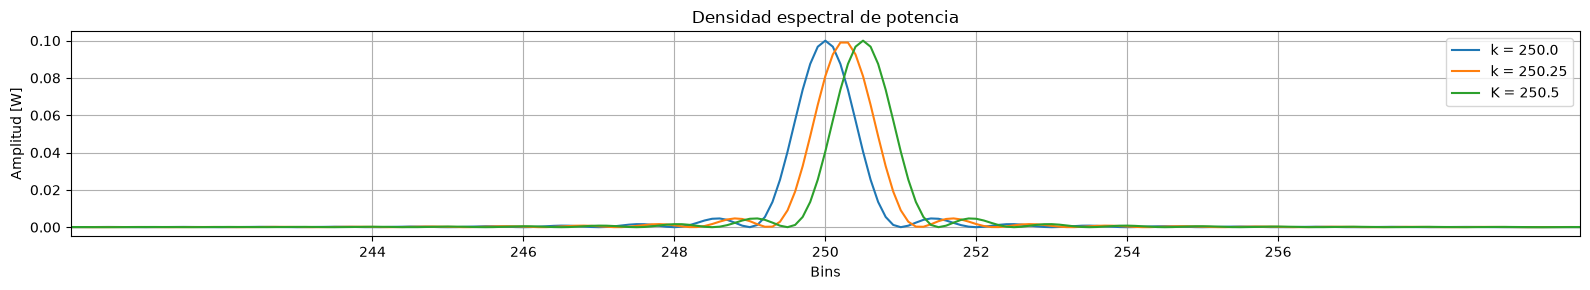

Potencia de señal 250.0 = 1.0000000000000004
Potencia de señal 250.25 = 0.9989997996855949
Potencia de señal 250.5 = 0.999999997486706


In [5]:
xx0tr_pot_pad = parseval_pad(xx0_pad)
xx1tr_pot_pad = parseval_pad(xx1_pad)
xx2tr_pot_pad = parseval_pad(xx2_pad)

plt.figure(3, figsize=(16,3))
plt.grid(True)
plt.plot(frec_pad, xx0tr_pot_pad)
plt.plot(frec_pad, xx1tr_pot_pad)
plt.plot(frec_pad, xx2tr_pot_pad)
plt.title("Densidad espectral de potencia")
plt.xlabel("Bins")
plt.ylabel("Amplitud [W]")
plt.xlim(240, 260)
plt.xticks([244, 246, 248, 250, 252, 254, 256])
plt.legend([f'k = {k0}',
            f'k = {k1}',
            f'K = {k2}'])
plt.tight_layout()
plt.show()
print(f'Potencia de señal {k0} = {np.sum(xx0tr_pot_pad)}')
print(f'Potencia de señal {k1} = {np.sum(xx1tr_pot_pad)}')
print(f'Potencia de señal {k2} = {np.sum(xx2tr_pot_pad)}')

La potencia total de cada señal se conserva pero ahora la desndidad espectral se reparte en bins adyacentes a causa de ahora tener una mayor resolucion espectral.

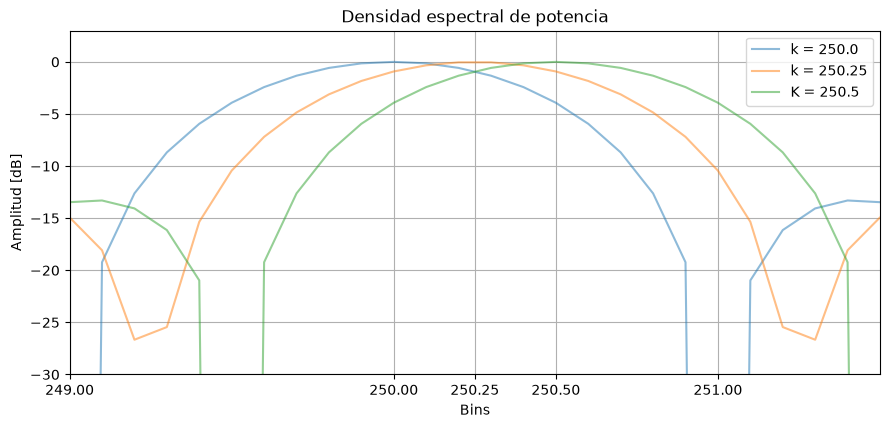

In [6]:
plt.figure(4, figsize=(9,12))
plt.subplot(3,1,1)
plt.grid(True)
plt.plot(frec_pad, xx0tr_pad, alpha = 0.5)
plt.plot(frec_pad, xx1tr_pad, alpha = 0.5)
plt.plot(frec_pad, xx2tr_pad, alpha = 0.5)
plt.title("Densidad espectral de potencia")
plt.xlabel("Bins")
plt.ylabel("Amplitud [dB]")
plt.ylim(-30,3)
plt.xlim(249, 251.5)
plt.xticks([249, 250, 250.25, 250.5, 251,])
plt.legend([f'k = {k0}',
            f'k = {k1}',
            f'K = {k2}'])
plt.tight_layout()
plt.show()

En conclusion, las señales que nos son multiplos enteros de la resolucion espectral conservaran su potencia pero, debido al derrame espectral, la potencia se ve repartida en bins adyacentes. La herramienta zero-padding permite aumentar la resolucion espectral sin aumentar la energia de la señal, permitiendo observar la densidad espectral de potencia con mas detalle. 